# Convergence Tests
This notebook reproduces a compact convergence comparison for the three screening mechanisms.

It shows how the numerical error changes with:
- solver tolerance,
- edge smoothing width $\varepsilon$,
- outer domain size $x_\mathrm{max}$.

The final figure combines Vainshtein, Chameleon, and Phaedrus in one plot.

In [21]:
# Setup: import local modules from ../main
import sys, os, importlib, warnings

warnings.filterwarnings("ignore")

repo_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
main_dir = os.path.join(repo_root, "main")
if main_dir not in sys.path:
    sys.path.insert(0, main_dir)

import physics_utils as _physics_mod
importlib.reload(_physics_mod)
import core_solver as _core_solver_mod
importlib.reload(_core_solver_mod)

from core_solver import solve_scalar_bvp

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

[warn] exterior μ contribution (3.459e+02) is >0.1% of interior μ (1.633e+04); enabling asymptotic_bc
[warn] exterior μ contribution (3.459e+02) is >0.1% of interior μ (1.633e+04); consider reducing delta_inf or using asymptotic_bc
[warn] exterior μ contribution (5.898e+02) is >0.1% of interior μ (1.475e+04); enabling asymptotic_bc
[warn] exterior μ contribution (5.898e+02) is >0.1% of interior μ (1.475e+04); consider reducing delta_inf or using asymptotic_bc
[warn] exterior μ contribution (1.667e-02) is >0.1% of interior μ (3.129e+00); enabling asymptotic_bc
[warn] exterior μ contribution (1.667e-02) is >0.1% of interior μ (3.129e+00); consider reducing delta_inf or using asymptotic_bc
[warn] exterior μ contribution (3.130e+00) is >0.1% of interior μ (3.138e+00); enabling asymptotic_bc
[warn] exterior μ contribution (3.130e+00) is >0.1% of interior μ (3.138e+00); consider reducing delta_inf or using asymptotic_bc
[warn] exterior μ contribution (3.130e+00) is >0.1% of interior μ (3.138

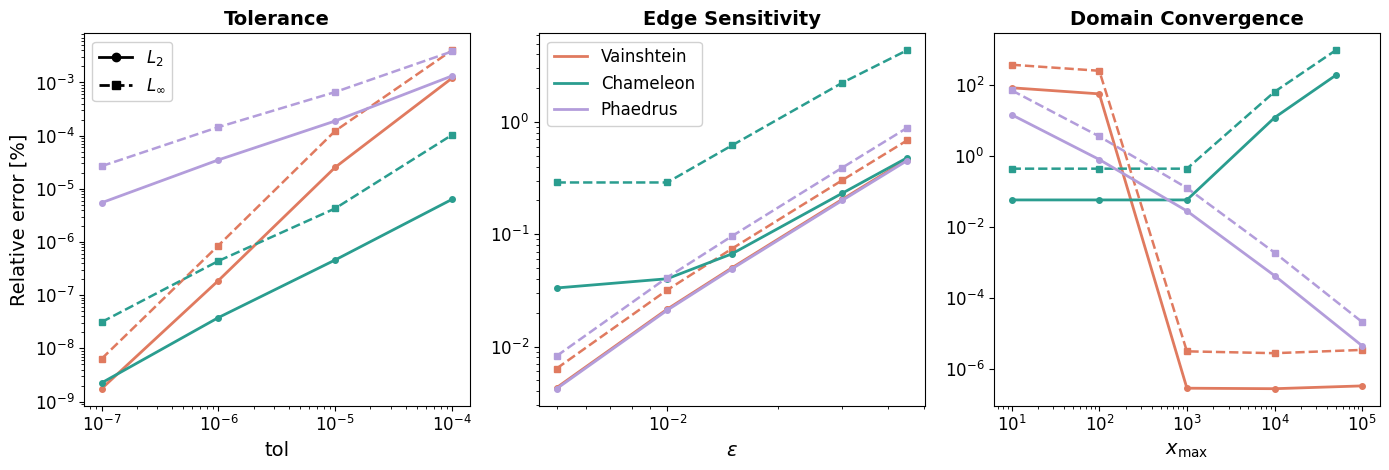

Saved: combined_convergence_1x3.png


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcdefaults()

def _plot_on_ax(ax, xvals, errs, color, label_prefix=""):
    L2 = np.array([e.get("L2", np.nan) for e in errs], dtype=float)
    Linf = np.array([e.get("L_inf", np.nan) for e in errs], dtype=float)
    xvals = np.array(xvals, dtype=float)

    mask = np.isfinite(L2) & np.isfinite(Linf) & (L2 > 0) & (Linf > 0)
    if not mask.any():
        return

    idx = np.argsort(xvals[mask])
    xp, L2p, Lip = xvals[mask][idx], L2[mask][idx], Linf[mask][idx]

    ax.loglog(xp, L2p, "o-", color=color, markersize=4, linewidth=2.0,
              label=f"{label_prefix} $L_2$")
    ax.loglog(xp, Lip, "s--", color=color, markersize=4, linewidth=1.8,
              label=f"{label_prefix} $L_\\infty$")

def _flux_errors_normalised(sols, x_eval):
    x2 = x_eval**2
    y_ref = x2 * sols[-1].sol(x_eval)[1]
    rms_ref = float(np.sqrt(np.mean(y_ref**2)))
    out = []
    for sol in sols:
        d = x2 * sol.sol(x_eval)[1] - y_ref
        out.append({
            "L2": float(np.sqrt(np.mean(d**2))) / rms_ref * 100,
            "L_inf": float(np.max(np.abs(d))) / rms_ref * 100,
        })
    return out

def _flux_errors_normalised_vs_ref(sols, x_eval, sol_ref):
    x2 = x_eval**2
    y_ref = x2 * sol_ref.sol(x_eval)[1]
    rms_ref = float(np.sqrt(np.mean(y_ref**2)))
    out = []
    for sol in sols:
        d = x2 * sol.sol(x_eval)[1] - y_ref
        out.append({
            "L2": float(np.sqrt(np.mean(d**2))) / rms_ref * 100,
            "L_inf": float(np.max(np.abs(d))) / rms_ref * 100,
        })
    return out

def _Q_errors_normalised(sols, x_eval, sol_ref):
    Q_ref = sol_ref.sol(x_eval)[0]
    rms_ref = float(np.sqrt(np.mean(Q_ref**2)))
    out = []
    for sol in sols:
        d = sol.sol(x_eval)[0] - Q_ref
        out.append({
            "L2": float(np.sqrt(np.mean(d**2))) / rms_ref * 100,
            "L_inf": float(np.max(np.abs(d))) / rms_ref * 100,
        })
    return out

v_base = dict(A=1.0, B=0.0, C=0.0, D=0.0, E=0.0, F=1.0, S=1.0,
              delta_c=1e5, delta_inf=1e-10, eps_edge=0.015,
              xmin=1e-2, xmax=1e5, tol=1e-6, homotopy=False,
              max_nodes=2_000_000, Q_inf=0.0)

c_base = dict(A=1.0, B=-1e1, C=-1e1, D=0.0, E=0.0, F=0.0, S=1.0,
              delta_c=1e3, delta_inf=1e-10, eps_edge=0.015,
              xmin=1e-2, xmax=1e2, tol=1e-9, homotopy=False,
              max_nodes=3_000_000, Q_inf=0.0)
c_xmax_ref = 1e3
c_ref_kwargs = dict(c_base, xmax=c_xmax_ref, npoints=2000, tol=1e-9, eps_edge=0.005)

p_base = dict(A=1.0, B=0.0, C=0.0, D=1.0, E=1.0, F=0.0, S=1.0,
              delta_c=1e3, delta_inf=0.0, eps_edge=0.015,
              xmin=1e-2, xmax=1e5, tol=1e-6, homotopy=True,
              max_nodes=3_000_000, Q_inf=0.0)

tol_series = [1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
edge_series = [0.045, 0.03, 0.015, 0.01, 0.005, 0.0025]
xmax_v = [1e1, 1e2, 1e3, 1e4, 1e5, 1e6]
xmax_c = [1e1, 1e2, 1e3, 1e4, 5e4]
xmax_p = [1e1, 1e2, 1e3, 1e4, 1e5, 1e6]

p_tol_candidates = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4]
p_tol_kwargs = dict(p_base)
p_tol_kwargs["xmax"] = 1e4
p_tol_kwargs["xmin"] = 1e-1
p_tol_kwargs["delta_c"] = 1e2
p_tol_kwargs["max_nodes"] = 100_000_000
p_tol_kwargs["homotopy"] = True

# Vainshtein
sols = [solve_scalar_bvp(**{**v_base, "tol": float(t), "npoints": 1600}) for t in tol_series]
x_eval_v = np.logspace(np.log10(v_base["xmin"]), np.log10(v_base["xmax"]), 1200)
v_tol_errs = _flux_errors_normalised(sols, x_eval_v)
sols = [solve_scalar_bvp(**{**v_base, "eps_edge": float(ee), "npoints": 1600}) for ee in edge_series]
v_edge_errs = _flux_errors_normalised(sols, x_eval_v)
x_eval_vd = np.logspace(np.log10(v_base["xmin"]), np.log10(9.0), 600)
sols = [solve_scalar_bvp(**{**v_base, "xmax": float(xm), "npoints": 1600}) for xm in sorted(xmax_v)]
v_dom_errs = _flux_errors_normalised(sols, x_eval_vd)

# Chameleon
sol_ref_c = solve_scalar_bvp(**c_ref_kwargs)
sols = [solve_scalar_bvp(**{**c_base, "tol": float(t), "npoints": 2000, "xmax": c_xmax_ref, "eps_edge": 0.005}) for t in tol_series]
x_eval_c = np.logspace(np.log10(c_base["xmin"]), np.log10(c_xmax_ref), 1200)
c_tol_errs = _Q_errors_normalised(sols, x_eval_c, sol_ref_c)
sols = [solve_scalar_bvp(**{**c_base, "eps_edge": float(ee), "npoints": 1600}) for ee in edge_series]
c_edge_errs = _Q_errors_normalised(sols, x_eval_c, sol_ref_c)
x_eval_cd = np.logspace(np.log10(c_base["xmin"]), np.log10(4.0), 600)
sols = [solve_scalar_bvp(**{**c_base, "xmax": float(xm), "npoints": 1600}) for xm in sorted(xmax_c)]
c_dom_errs = _Q_errors_normalised(sols, x_eval_cd, sol_ref_c)
c_tol_xvals_plot = tol_series[:-1]
c_tol_errs_plot = c_tol_errs[:-1]
c_edge_xvals_plot = edge_series[:-1]
c_edge_errs_plot = c_edge_errs[:-1]

# Phaedrus
p_probe_sols = {}
for t in sorted(p_tol_candidates):
    kw = dict(p_tol_kwargs)
    kw["tol"] = float(t)
    kw["npoints"] = 3000
    sol = solve_scalar_bvp(**kw)
    ok = getattr(sol, "success", False)
    hit_limit = len(sol.x) >= p_tol_kwargs["max_nodes"] * 0.95
    if ok and not hit_limit:
        p_probe_sols[t] = sol

if p_probe_sols:
    p_converged_tols = sorted(p_probe_sols.keys())
    p_ref_tol = p_converged_tols[0]
    p_plot_tols = [t for t in p_converged_tols if t > p_ref_tol]
    sol_ref_p = p_probe_sols[p_ref_tol]
    x_eval_p_tol = np.logspace(np.log10(p_tol_kwargs["xmin"]), np.log10(p_tol_kwargs["xmax"]), 1200)
    p_plot_sols = [p_probe_sols[t] for t in p_plot_tols]
    p_tol_errs = _flux_errors_normalised_vs_ref(p_plot_sols, x_eval_p_tol, sol_ref_p)
    p_tol_xvals = p_plot_tols
else:
    p_tol_xvals = []
    p_tol_errs = []

sols = [solve_scalar_bvp(**{**p_base, "eps_edge": float(ee), "npoints": 1600}) for ee in edge_series]
x_eval_p = np.logspace(np.log10(p_base["xmin"]), np.log10(p_base["xmax"]), 1200)
p_edge_errs = _flux_errors_normalised(sols, x_eval_p)
x_eval_pd = np.logspace(np.log10(p_base["xmin"]), np.log10(9.0), 600)
sols = [solve_scalar_bvp(**{**p_base, "xmax": float(xm), "npoints": 1600}) for xm in sorted(xmax_p)]
p_dom_errs = _flux_errors_normalised(sols, x_eval_pd)

colours = {
    "Vainshtein": "#E07A5F",
    "Chameleon": "#2A9D8F",
    "Phaedrus": "#B39DDB",
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
col_titles = [r"Tolerance", r"Edge Sensitivity", r"Domain Convergence"]
col_xlabels = [r"tol", r"$\varepsilon$", r"$x_\mathrm{max}$"]
ylabel = "Relative error [%]"

ax = axes[0]
_plot_on_ax(ax, tol_series, v_tol_errs, color=colours["Vainshtein"], label_prefix="Vainshtein")
_plot_on_ax(ax, c_tol_xvals_plot, c_tol_errs_plot, color=colours["Chameleon"], label_prefix="Chameleon")
_plot_on_ax(ax, p_tol_xvals, p_tol_errs, color=colours["Phaedrus"], label_prefix="Phaedrus")
ax.set_xlabel(col_xlabels[0], fontsize=14)
ax.set_ylabel(ylabel, fontsize=14)
ax.set_title(col_titles[0], fontweight="bold", fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, which="both", alpha=0)

ax = axes[1]
_plot_on_ax(ax, edge_series, v_edge_errs, color=colours["Vainshtein"], label_prefix="Vainshtein")
_plot_on_ax(ax, c_edge_xvals_plot, c_edge_errs_plot, color=colours["Chameleon"], label_prefix="Chameleon")
_plot_on_ax(ax, edge_series, p_edge_errs, color=colours["Phaedrus"], label_prefix="Phaedrus")
ax.set_xlabel(col_xlabels[1], fontsize=14)
ax.set_title(col_titles[1], fontweight="bold", fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, which="both", alpha=0)

ax = axes[2]
_plot_on_ax(ax, sorted(xmax_v), v_dom_errs, color=colours["Vainshtein"], label_prefix="Vainshtein")
_plot_on_ax(ax, sorted(xmax_c), c_dom_errs, color=colours["Chameleon"], label_prefix="Chameleon")
_plot_on_ax(ax, sorted(xmax_p), p_dom_errs, color=colours["Phaedrus"], label_prefix="Phaedrus")
ax.set_xlabel(col_xlabels[2], fontsize=14)
ax.set_title(col_titles[2], fontweight="bold", fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, which="both", alpha=0)

error_types_legend = [
    Line2D([0], [0], color="k", marker="o", lw=2, linestyle='-', label=r"$L_2$"),
    Line2D([0], [0], color="k", marker="s", lw=2, linestyle='--', label=r"$L_\infty$"),
]
axes[0].legend(handles=error_types_legend, loc="upper left", fontsize=12, frameon=True, framealpha=0.9)

mechanisms_legend = [
    Line2D([0], [0], color=colours["Vainshtein"], lw=2, label="Vainshtein"),
    Line2D([0], [0], color=colours["Chameleon"], lw=2, label="Chameleon"),
    Line2D([0], [0], color=colours["Phaedrus"], lw=2, label="Phaedrus"),
]
axes[1].legend(handles=mechanisms_legend, loc="upper left", fontsize=12, frameon=True, framealpha=0.9)

plt.tight_layout()
plt.savefig("combined_convergence_1x3.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: combined_convergence_1x3.png")